In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare
import glob
import openpyxl

In [2]:
import pandas as pd
import glob
import os

# --- Load all text files and add a Model column ---
file_list = glob.glob("text/*.txt")
df_list = []

for f in file_list:
    df_temp = pd.read_csv(f, sep=r'\s+', engine='python')
    
    # Keep only relevant columns
    columns_to_keep = ['Lang', 'mean_acc', 'std_acc', 'mean_macro_f1', 'std_macro_f1']
    df_temp = df_temp[columns_to_keep]
    
    # Extract model name from filename (without extension)
    model_name = os.path.splitext(os.path.basename(f))[0]
    df_temp['Model'] = model_name
    
    df_list.append(df_temp)

# --- Combine all files ---
df_all = pd.concat(df_list, ignore_index=True)

# --- Sort by mean_macro_f1 ---
df_sorted = df_all.sort_values("mean_macro_f1", ascending=False)

# --- Save cleaned and sorted data ---
df_sorted.to_excel("combined_cleaned_sorted_with_model.xlsx", index=False)

# --- Quick check ---
print(df_sorted.head())


   Lang  mean_acc   std_acc  mean_macro_f1  std_macro_f1     Model
0   tel  0.866022  0.006564       0.865566      0.006852    bge_m3
66  tel  0.859251  0.008596       0.858375      0.008340     Labse
1   zho  0.857243  0.004333       0.856943      0.004469    bge_m3
22  nep  0.845885  0.016115       0.845490      0.016164  e5_large
23  tel  0.846601  0.032197       0.844590      0.035338  e5_large


Best model per language:
     Lang             Model  mean_macro_f1
86   amh              jina       0.707558
22   arb          e5_large       0.790431
14   ben          e5_large       0.818251
95   deu          e5_large       0.677250
33   eng  multi_mpnet_base       0.769238
27   fas              jina       0.780139
46   hau             Labse       0.753436
49   hin          e5_large       0.750551
102  ita            bge_m3       0.636362
91   khm             Labse       0.686723
15   mya            bge_m3       0.818140
3    nep          e5_large       0.845490
25   ori              jina       0.782848
52   pan            bge_m3       0.747251
36   pol              jina       0.765281
50   rus              jina       0.750193
69   spa              jina       0.731860
40   swa            bge_m3       0.759091
0    tel            bge_m3       0.865566
35   tur          e5_large       0.766803
64   urd              jina       0.736769
2    zho            bge_m3       0.856943

Average

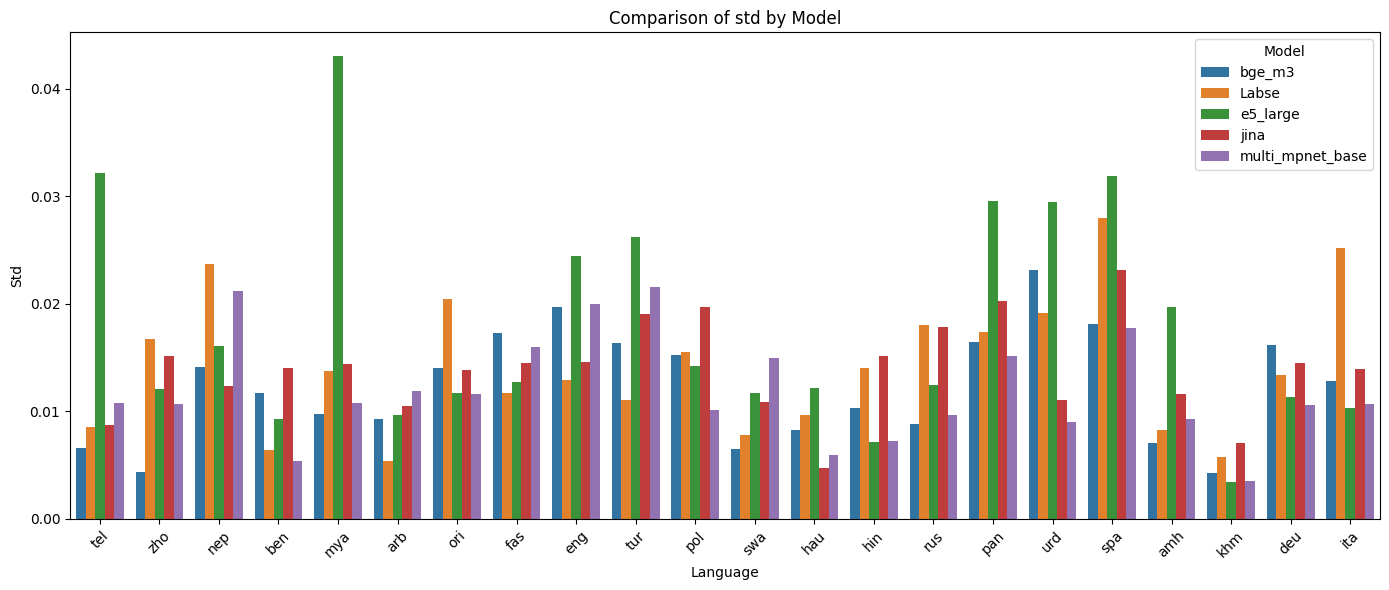

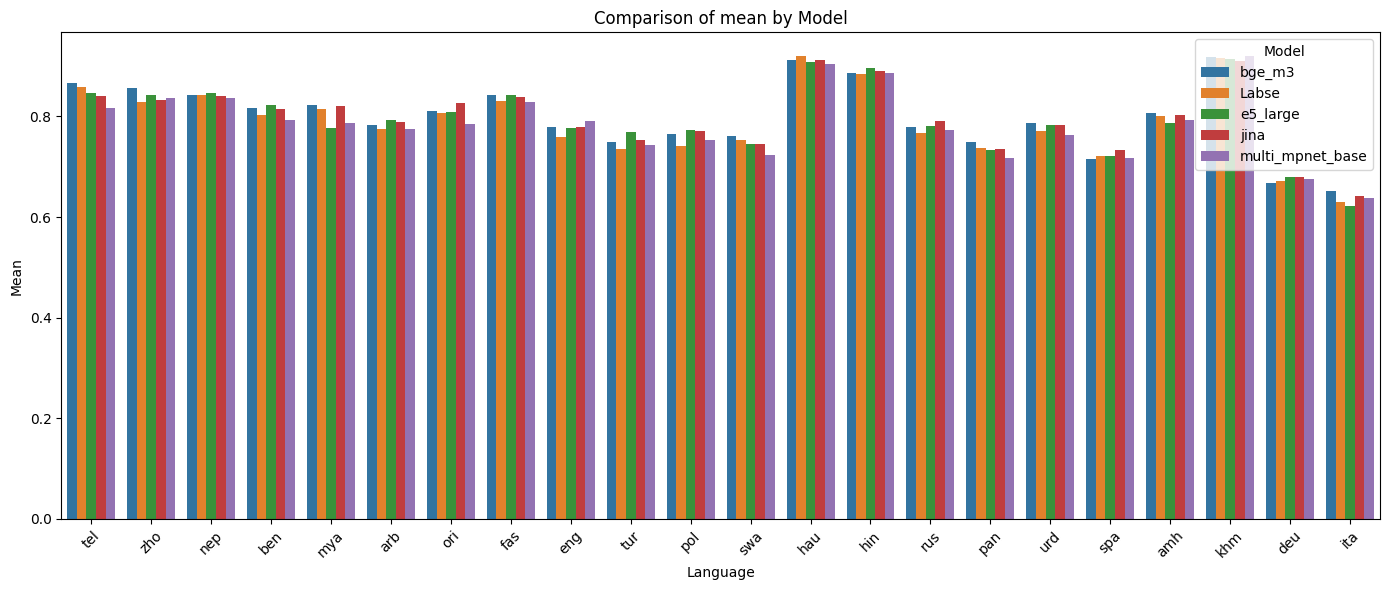

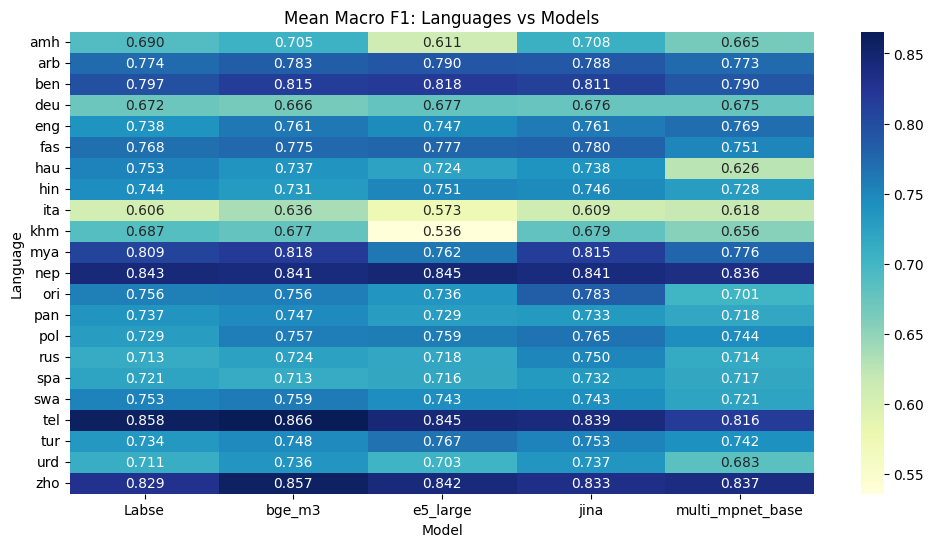

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load the combined file with Model column ---
df_all = pd.read_excel("combined_cleaned_sorted_with_model.xlsx")

# --- 1. Best model per language ---
best_model_per_lang = df_all.loc[df_all.groupby('Lang')['mean_macro_f1'].idxmax()]
print("Best model per language:\n", best_model_per_lang[['Lang', 'Model', 'mean_macro_f1']])

# --- 2. Summary statistics per model ---
model_summary = df_all.groupby('Model')[['mean_acc', 'mean_macro_f1']].mean().sort_values('mean_macro_f1', ascending=False)
print("\nAverage performance per model:\n", model_summary)

# --- 3. Pivot table for easier comparison ---
pivot_f1 = df_all.pivot(index='Lang', columns='Model', values='mean_macro_f1')
print("\nMean Macro F1 per language per model:\n", pivot_f1)

# --- 4. Visualization ---

# a) Bar plot of mean_macro_f1 for all models
plt.figure(figsize=(14,6))
sns.barplot(x='Lang', y='std_acc', hue='Model', data=df_all)
plt.title('Comparison of std by Model')
plt.ylabel('Std')
plt.xlabel('Language')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,6))
sns.barplot(x='Lang', y='mean_acc', hue='Model', data=df_all)
plt.title('Comparison of mean by Model')
plt.ylabel('Mean')
plt.xlabel('Language')
plt.xticks(rotation=45)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

# b) Heatmap of models vs languages
plt.figure(figsize=(12,6))
sns.heatmap(pivot_f1, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Mean Macro F1: Languages vs Models")
plt.ylabel("Language")
plt.xlabel("Model")
plt.show()


In [19]:
pivot = df_all.pivot(index="language", columns="model", values="mean_macro_f1")
print("\nPivot table (Macro-F1):")
print(pivot)

ValueError: Index contains duplicate entries, cannot reshape